In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"faiqaahmad","key":"531356e12be9302d20d043c8ab9de0c5"}'}

In [ ]:
!pip install kaggle --quiet

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d vinayak123tyagi/bearing-dataset --unzip -p /content/nasa_ims

Dataset URL: https://www.kaggle.com/datasets/vinayak123tyagi/bearing-dataset
License(s): U.S. Government Works
100% 1.56G/1.56G [00:39<00:00, 42.5MB/s]



Own dataset RE

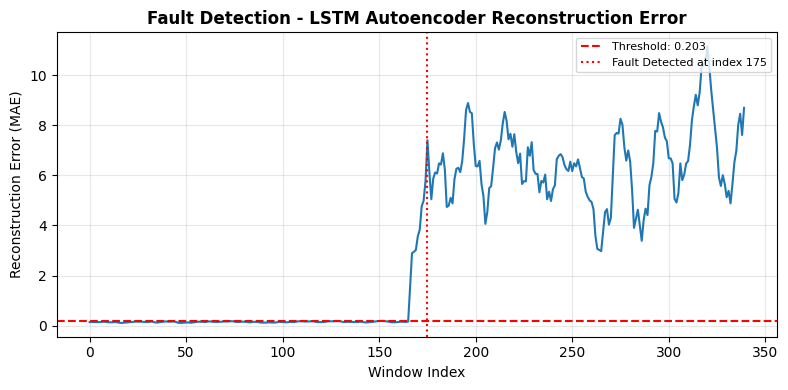

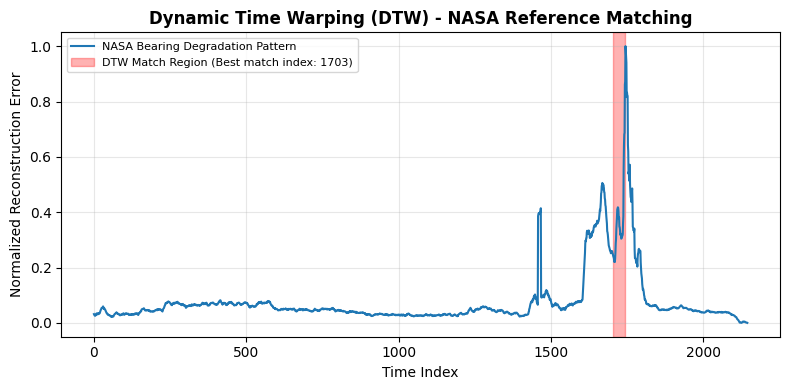

Estimated Time to Failure: 100.72 hours
CNN Predicted Fault Type: RE


In [ ]:
# =========================
# 1. IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from keras.models import Model
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Input

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter


# =========================
# 2. SAFE FUNCTION
# =========================
def safe(x):
    return 0 if (np.isnan(x) or np.isinf(x)) else x


# =========================
# 3. FEATURE EXTRACTION
# =========================
def extract_features(ax, ay, az, fs=1000):

    feats = []

    for axis in [ax, ay, az]:

        mean = safe(np.mean(axis))
        std = safe(np.std(axis))
        rms = safe(np.sqrt(np.mean(axis**2)))
        peak = safe(np.max(np.abs(axis)))
        ptp = safe(np.ptp(axis))
        sk = safe(skew(axis))
        kurt = safe(kurtosis(axis))

        fft_vals = np.abs(fft(axis))[:len(axis)//2]
        freqs = fftfreq(len(axis), 1/fs)[:len(axis)//2]

        centroid = safe(np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-8))
        peak_freq = freqs[np.argmax(fft_vals)] if len(fft_vals) > 0 else 0

        feats.extend([mean, std, rms, peak, ptp, sk, kurt, centroid, peak_freq])

    return feats


# =========================
# 4. LOAD CSV
# =========================
def load_csv(path, label_col='ground_truth'):

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    for c in ['ax','ay','az']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df = df.dropna()

    signal = df[['ax','ay','az']].values.astype(np.float32)
    labels = df[label_col].values if label_col in df.columns else None
    timestamps = pd.to_datetime(df['ts']) if 'ts' in df.columns else None

    return signal, labels, timestamps


# =========================
# 5. WINDOWING
# =========================
def create_windows(signal, win=1024, step=512):

    X = []

    for i in range(0, len(signal)-win, step):
        ax, ay, az = signal[i:i+win].T
        X.append(extract_features(ax, ay, az))

    return np.array(X, dtype=np.float32)


# =========================
# 6. SEQUENCES
# =========================
def create_sequences(data, seq_len=10):

    return np.array([
        data[i:i+seq_len]
        for i in range(len(data)-seq_len)
    ], dtype=np.float32)


# =========================
# 7. LSTM AUTOENCODER (FIXED ARCHITECTURE)
# =========================
def build_model(X):

    inp = Input(shape=(X.shape[1], X.shape[2]))

    # Encoder (MATCH SECOND CODE)
    x = LSTM(32, return_sequences=True)(inp)
    x = LSTM(8, return_sequences=False)(x)

    # Bottleneck
    x = RepeatVector(X.shape[1])(x)

    # Decoder
    x = LSTM(8, return_sequences=True)(x)
    x = LSTM(32, return_sequences=True)(x)

    out = TimeDistributed(Dense(X.shape[2]))(x)

    model = Model(inp, out)
    model.compile(optimizer='adam', loss='mae')

    return model


# =========================
# 8. LOAD DATA
# =========================
normal_signal, _, _ = load_csv("Normal.csv")
test_signal, test_labels, test_timestamps = load_csv("test.csv")


# =========================
# 9. FEATURE BUILDING
# =========================
X_normal = create_windows(normal_signal)
X_test = create_windows(test_signal)


# =========================
# 10. SCALING
# =========================
scaler = MinMaxScaler()
X_normal_scaled = scaler.fit_transform(X_normal)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.save")


# =========================
# 11. SEQUENCES
# =========================
seq_len = 10

X_train_seq = create_sequences(X_normal_scaled, seq_len)
X_test_seq = create_sequences(X_test_scaled, seq_len)


# =========================
# 12. TRAIN MODEL
# =========================
model = build_model(X_train_seq)

model.fit(
    X_train_seq,
    X_train_seq,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0  # Silent training
)

model.save("lstm_ae.h5")


# =========================
# 13. LOSS COMPUTATION
# =========================
train_pred = model.predict(X_train_seq, verbose=0)
train_loss = np.mean(np.abs(train_pred - X_train_seq), axis=(1,2))

test_pred = model.predict(X_test_seq, verbose=0)
test_loss = np.mean(np.abs(test_pred - X_test_seq), axis=(1,2))


# =========================
# 14. THRESHOLD
# =========================
threshold = np.mean(train_loss) + 3*np.std(train_loss)


# =========================
# 15. DETECT t2
# =========================
def detect_t2(loss, threshold, K=10):

    count = 0
    t2 = None

    for i, l in enumerate(loss):

        if l > threshold:
            count += 1
            if count >= K:
                t2 = i
                break
        else:
            count = 0

    return t2


t2 = detect_t2(test_loss, threshold)

if t2 is None:
    raise ValueError("No fault detected")


# =========================
# 16. LOAD NASA DATA
# =========================
def load_nasa(data_dir):

    folder = os.path.join(data_dir, "1st_test", "1st_test")
    files = sorted(os.listdir(folder))

    records = []

    for f in files:

        if ".pdf" in f:
            continue

        parts = f.split('.')
        if len(parts) < 6:
            continue

        try:
            ts = pd.Timestamp(
                int(parts[0]), int(parts[1]), int(parts[2]),
                int(parts[3]), int(parts[4]), int(parts[5])
            )

            df = pd.read_csv(os.path.join(folder, f), sep=r"\s+", header=None)
            df = df.iloc[:, :8].dropna()

            x = df[6].values
            y = df[7].values
            z = np.abs(x - y)

            feat = extract_features(x, y, z)
            records.append([ts, feat])

        except:
            continue

    X = np.array([r[1] for r in records])
    t = np.array([r[0] for r in records])

    return X, t


nasa_X, nasa_t = load_nasa("/content/nasa_ims")


# =========================
# 17. NASA LOSS
# =========================
nasa_scaled = scaler.transform(nasa_X)
nasa_seq = create_sequences(nasa_scaled, seq_len)

nasa_pred = model.predict(nasa_seq, verbose=0)
nasa_loss = np.mean(np.abs(nasa_pred - nasa_seq), axis=(1,2))


# =========================
# 18. DTW
# =========================
def dtw_distance(s1, s2):

    n, m = len(s1), len(s2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0

    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw[i, j] = cost + min(
                dtw[i-1, j],
                dtw[i, j-1],
                dtw[i-1, j-1]
            )

    return dtw[n, m]


# =========================
# 19. DTW MAPPING
# =========================
nasa_norm = (nasa_loss - nasa_loss.min()) / (nasa_loss.max() - nasa_loss.min() + 1e-8)
test_norm = (test_loss - test_loss.min()) / (test_loss.max() - test_loss.min() + 1e-8)

window_size = 20

start = max(0, t2 - window_size)
end = min(len(test_norm), t2 + window_size)

test_pattern = test_norm[start:end]

best_match = None
best_dist = float("inf")

for i in range(len(nasa_norm) - len(test_pattern)):

    seg = nasa_norm[i:i+len(test_pattern)]
    dist = dtw_distance(test_pattern, seg)

    if dist < best_dist:
        best_dist = dist
        best_match = i


# =========================
# 20. RUL
# =========================
failure_idx = len(nasa_t) - 1
time_to_failure = nasa_t[failure_idx] - nasa_t[best_match]

hours = time_to_failure / np.timedelta64(1, 'h')


# =========================
# 21. PLOTS (REDUCED SIZE)
# =========================

# Create first figure - Fault Detection (reduced size)
plt.figure(figsize=(8,4))
plt.plot(test_loss, linewidth=1.5)
plt.axhline(threshold, linestyle='--', color='red', linewidth=1.5, label=f'Threshold: {threshold:.3f}')
if t2 is not None:
    plt.axvline(t2, color='red', linewidth=1.5, linestyle=':', label=f'Fault Detected at index {t2}')
plt.title("Fault Detection - LSTM Autoencoder Reconstruction Error", fontsize=12, fontweight='bold')
plt.xlabel("Window Index", fontsize=10)
plt.ylabel("Reconstruction Error (MAE)", fontsize=10)
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Add spacing by printing blank lines
print("\n" * 2)

# Create second figure - DTW Match (reduced size)
plt.figure(figsize=(8,4))
plt.plot(nasa_norm, linewidth=1.5, label='NASA Bearing Degradation Pattern')
plt.axvspan(
    best_match,
    best_match + len(test_pattern),
    color='red',
    alpha=0.3,
    label=f'DTW Match Region (Best match index: {best_match})'
)
plt.title("Dynamic Time Warping (DTW) - NASA Reference Matching", fontsize=12, fontweight='bold')
plt.xlabel("Time Index", fontsize=10)
plt.ylabel("Normalized Reconstruction Error", fontsize=10)
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# 22. CNN FAULT CLASSIFIER
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

window_size = 50
step_size = 5


# -------------------------
# LOAD RAW SIGNAL
# -------------------------
def load_vibration(file):
    df = pd.read_csv(file, low_memory=False)
    df.columns = df.columns.str.strip()

    for c in ['ax', 'ay', 'az']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df = df.dropna(subset=['ax','ay','az'])
    return df[['ax','ay','az']].values.astype(np.float32)


# -------------------------
# CNN MODEL
# -------------------------
class FaultCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(32 * (window_size // 4), 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


# -------------------------
# LABEL MAP
# -------------------------
label_map = {
    'Normal': 0,
    'Inner': 1,
    'Outer': 2,
    'RE': 3
}

inv_map = {v: k for k, v in label_map.items()}


# -------------------------
# TRAIN OR LOAD CNN
# -------------------------
cnn_model_file = "cnn_fault_model.pth"

cnn_model = FaultCNN(num_classes=4).to(device)

if os.path.exists(cnn_model_file):
    cnn_model.load_state_dict(torch.load(cnn_model_file, map_location=device))
    cnn_model.eval()
else:
    X_cnn, y_cnn = [], []

    fault_files = {
        'Inner': ['inner_L_S1_part1.csv'],
        'Outer': ['outer2__part1_with_ts.csv'],
        'RE': ['RE_part1_with_ts.csv']
    }

    for label, files in fault_files.items():
        for f in files:

            sig = load_vibration(f)

            # normalize per file
            sig = (sig - sig.mean(axis=0)) / (sig.std(axis=0) + 1e-8)

            for i in range(0, len(sig) - window_size, step_size):
                X_cnn.append(sig[i:i+window_size])
                y_cnn.append(label_map[label])

    X_cnn = np.array(X_cnn, dtype=np.float32)
    y_cnn = np.array(y_cnn)

    dataset = TensorDataset(
        torch.from_numpy(X_cnn),
        torch.from_numpy(y_cnn)
    )

    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    cnn_model.train()

    for epoch in range(15):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            loss = criterion(cnn_model(xb), yb)
            loss.backward()
            optimizer.step()

    torch.save(cnn_model.state_dict(), cnn_model_file)


# =========================
# 23. CNN INFERENCE ON TEST REGION
# =========================

if t2 is not None:

    sig_test = load_vibration("test.csv")

    sig_test = (sig_test - sig_test.mean(axis=0)) / (sig_test.std(axis=0) + 1e-8)

    # focus around fault region
    start = max(0, t2 * step_size - window_size * 10)
    end   = min(len(sig_test), t2 * step_size + window_size * 10)

    region = sig_test[start:end]

    X_test_cnn = []

    for i in range(0, len(region) - window_size, step_size):
        X_test_cnn.append(region[i:i+window_size])

    if len(X_test_cnn) > 0:
        X_test_cnn = np.array(X_test_cnn, dtype=np.float32)

        cnn_model.eval()

        with torch.no_grad():
            tensor = torch.from_numpy(X_test_cnn).float().to(device)
            outputs = cnn_model(tensor)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()

        final_label = Counter([inv_map[p] for p in preds]).most_common(1)[0][0]

        # PRINT BOTH LINES AT THE END
        print(f"Estimated Time to Failure: {float(hours):.2f} hours")
        print(f"CNN Predicted Fault Type: {final_label}")

else:
    print("CNN skipped because no fault detected (t2 is None)")

Own dataset Outer race

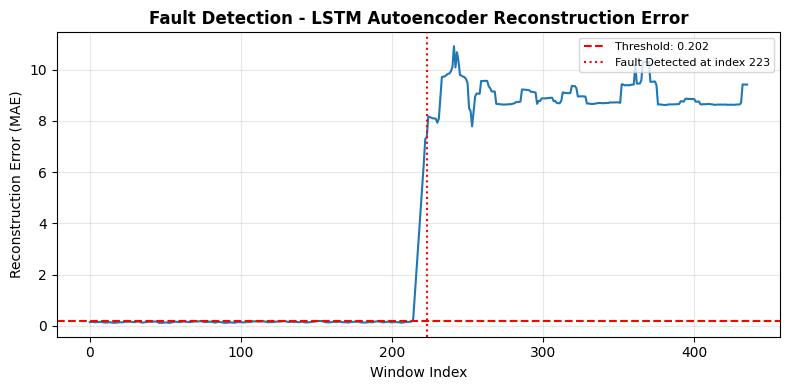

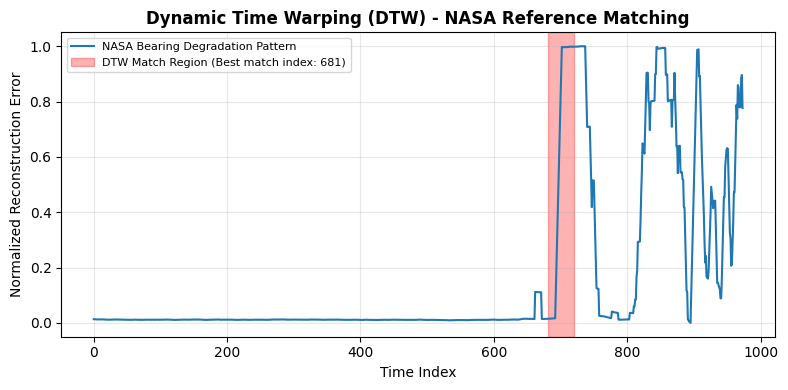

Estimated Time to Failure: 50.33 hours
CNN Predicted Fault Type: Outer


In [ ]:
# =========================
# 1. IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from keras.models import Model
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Input

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter


# =========================
# 2. SAFE FUNCTION
# =========================
def safe(x):
    return 0 if (np.isnan(x) or np.isinf(x)) else x


# =========================
# 3. FEATURE EXTRACTION
# =========================
def extract_features(ax, ay, az, fs=1000):

    feats = []

    for axis in [ax, ay, az]:

        mean = safe(np.mean(axis))
        std = safe(np.std(axis))
        rms = safe(np.sqrt(np.mean(axis**2)))
        peak = safe(np.max(np.abs(axis)))
        ptp = safe(np.ptp(axis))
        sk = safe(skew(axis))
        kurt = safe(kurtosis(axis))

        fft_vals = np.abs(fft(axis))[:len(axis)//2]
        freqs = fftfreq(len(axis), 1/fs)[:len(axis)//2]

        centroid = safe(np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-8))
        peak_freq = freqs[np.argmax(fft_vals)] if len(fft_vals) > 0 else 0

        feats.extend([mean, std, rms, peak, ptp, sk, kurt, centroid, peak_freq])

    return feats


# =========================
# 4. LOAD CSV
# =========================
def load_csv(path, label_col='ground_truth'):

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    for c in ['ax','ay','az']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df = df.dropna()

    signal = df[['ax','ay','az']].values.astype(np.float32)
    labels = df[label_col].values if label_col in df.columns else None
    timestamps = pd.to_datetime(df['ts']) if 'ts' in df.columns else None

    return signal, labels, timestamps


# =========================
# 5. WINDOWING
# =========================
def create_windows(signal, win=1024, step=512):

    X = []

    for i in range(0, len(signal)-win, step):
        ax, ay, az = signal[i:i+win].T
        X.append(extract_features(ax, ay, az))

    return np.array(X, dtype=np.float32)


# =========================
# 6. SEQUENCES
# =========================
def create_sequences(data, seq_len=10):

    return np.array([
        data[i:i+seq_len]
        for i in range(len(data)-seq_len)
    ], dtype=np.float32)


# =========================
# 7. LSTM AUTOENCODER (FIXED ARCHITECTURE)
# =========================
def build_model(X):

    inp = Input(shape=(X.shape[1], X.shape[2]))

    # Encoder (MATCH SECOND CODE)
    x = LSTM(32, return_sequences=True)(inp)
    x = LSTM(8, return_sequences=False)(x)

    # Bottleneck
    x = RepeatVector(X.shape[1])(x)

    # Decoder
    x = LSTM(8, return_sequences=True)(x)
    x = LSTM(32, return_sequences=True)(x)

    out = TimeDistributed(Dense(X.shape[2]))(x)

    model = Model(inp, out)
    model.compile(optimizer='adam', loss='mae')

    return model


# =========================
# 8. LOAD DATA
# =========================
normal_signal, _, _ = load_csv("Normal.csv")
test_signal, test_labels, test_timestamps = load_csv("test.csv")


# =========================
# 9. FEATURE BUILDING
# =========================
X_normal = create_windows(normal_signal)
X_test = create_windows(test_signal)


# =========================
# 10. SCALING
# =========================
scaler = MinMaxScaler()
X_normal_scaled = scaler.fit_transform(X_normal)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.save")


# =========================
# 11. SEQUENCES
# =========================
seq_len = 10

X_train_seq = create_sequences(X_normal_scaled, seq_len)
X_test_seq = create_sequences(X_test_scaled, seq_len)


# =========================
# 12. TRAIN MODEL
# =========================
model = build_model(X_train_seq)

model.fit(
    X_train_seq,
    X_train_seq,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0  # Silent training
)

model.save("lstm_ae.h5")


# =========================
# 13. LOSS COMPUTATION
# =========================
train_pred = model.predict(X_train_seq, verbose=0)
train_loss = np.mean(np.abs(train_pred - X_train_seq), axis=(1,2))

test_pred = model.predict(X_test_seq, verbose=0)
test_loss = np.mean(np.abs(test_pred - X_test_seq), axis=(1,2))


# =========================
# 14. THRESHOLD
# =========================
threshold = np.mean(train_loss) + 3*np.std(train_loss)


# =========================
# 15. DETECT t2
# =========================
def detect_t2(loss, threshold, K=10):

    count = 0
    t2 = None

    for i, l in enumerate(loss):

        if l > threshold:
            count += 1
            if count >= K:
                t2 = i
                break
        else:
            count = 0

    return t2


t2 = detect_t2(test_loss, threshold)

if t2 is None:
    raise ValueError("No fault detected")


# =========================
# 16. LOAD NASA DATA
# =========================
def load_nasa(data_dir):

    folder = os.path.join(data_dir, "2nd_test", "2nd_test")  # FIXED
    files = sorted(os.listdir(folder))

    records = []

    for f in files:

        if ".pdf" in f:
            continue

        try:
            parts = f.split('.')
            if len(parts) < 6:
                continue

            ts = pd.Timestamp(
                int(parts[0]), int(parts[1]), int(parts[2]),
                int(parts[3]), int(parts[4]), int(parts[5])
            )

            df = pd.read_csv(os.path.join(folder, f), sep=r"\s+", header=None)
            df = df.iloc[:, :4].dropna()

            x = df[0].values
            y = df[0].values
            z = np.abs(x - y)

            feat = extract_features(x, y, z)
            records.append([ts, feat])

        except:
            continue

    X = np.array([r[1] for r in records])
    t = np.array([r[0] for r in records])

    return X, t

nasa_X, nasa_t = load_nasa("/content/nasa_ims")


# =========================
# 17. NASA LOSS
# =========================
nasa_scaled = scaler.transform(nasa_X)
nasa_seq = create_sequences(nasa_scaled, seq_len)

nasa_pred = model.predict(nasa_seq, verbose=0)
nasa_loss = np.mean(np.abs(nasa_pred - nasa_seq), axis=(1,2))


# =========================
# 18. DTW
# =========================
def dtw_distance(s1, s2):

    n, m = len(s1), len(s2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0

    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw[i, j] = cost + min(
                dtw[i-1, j],
                dtw[i, j-1],
                dtw[i-1, j-1]
            )

    return dtw[n, m]


# =========================
# 19. DTW MAPPING
# =========================
nasa_norm = (nasa_loss - nasa_loss.min()) / (nasa_loss.max() - nasa_loss.min() + 1e-8)
test_norm = (test_loss - test_loss.min()) / (test_loss.max() - test_loss.min() + 1e-8)

window_size = 20

start = max(0, t2 - window_size)
end = min(len(test_norm), t2 + window_size)

test_pattern = test_norm[start:end]

best_match = None
best_dist = float("inf")

for i in range(len(nasa_norm) - len(test_pattern)):

    seg = nasa_norm[i:i+len(test_pattern)]
    dist = dtw_distance(test_pattern, seg)

    if dist < best_dist:
        best_dist = dist
        best_match = i


# =========================
# 20. RUL
# =========================
failure_idx = len(nasa_t) - 1
time_to_failure = nasa_t[failure_idx] - nasa_t[best_match]

hours = time_to_failure / np.timedelta64(1, 'h')


# =========================
# 21. PLOTS (REDUCED SIZE)
# =========================

# Create first figure - Fault Detection (reduced size)
plt.figure(figsize=(8,4))
plt.plot(test_loss, linewidth=1.5)
plt.axhline(threshold, linestyle='--', color='red', linewidth=1.5, label=f'Threshold: {threshold:.3f}')
if t2 is not None:
    plt.axvline(t2, color='red', linewidth=1.5, linestyle=':', label=f'Fault Detected at index {t2}')
plt.title("Fault Detection - LSTM Autoencoder Reconstruction Error", fontsize=12, fontweight='bold')
plt.xlabel("Window Index", fontsize=10)
plt.ylabel("Reconstruction Error (MAE)", fontsize=10)
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Add spacing by printing blank lines
print("\n" * 2)

# Create second figure - DTW Match (reduced size)
plt.figure(figsize=(8,4))
plt.plot(nasa_norm, linewidth=1.5, label='NASA Bearing Degradation Pattern')
plt.axvspan(
    best_match,
    best_match + len(test_pattern),
    color='red',
    alpha=0.3,
    label=f'DTW Match Region (Best match index: {best_match})'
)
plt.title("Dynamic Time Warping (DTW) - NASA Reference Matching", fontsize=12, fontweight='bold')
plt.xlabel("Time Index", fontsize=10)
plt.ylabel("Normalized Reconstruction Error", fontsize=10)
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# 22. CNN FAULT CLASSIFIER
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

window_size = 50
step_size = 5


# -------------------------
# LOAD RAW SIGNAL
# -------------------------
def load_vibration(file):
    df = pd.read_csv(file, low_memory=False)
    df.columns = df.columns.str.strip()

    for c in ['ax', 'ay', 'az']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df = df.dropna(subset=['ax','ay','az'])
    return df[['ax','ay','az']].values.astype(np.float32)


# -------------------------
# CNN MODEL
# -------------------------
class FaultCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(32 * (window_size // 4), 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


# -------------------------
# LABEL MAP
# -------------------------
label_map = {
    'Normal': 0,
    'Inner': 1,
    'Outer': 2,
    'RE': 3
}

inv_map = {v: k for k, v in label_map.items()}


# -------------------------
# TRAIN OR LOAD CNN
# -------------------------
cnn_model_file = "cnn_fault_model.pth"

cnn_model = FaultCNN(num_classes=4).to(device)

if os.path.exists(cnn_model_file):
    cnn_model.load_state_dict(torch.load(cnn_model_file, map_location=device))
    cnn_model.eval()
else:
    X_cnn, y_cnn = [], []

    fault_files = {
        'Inner': ['inner_L_S1_part1.csv'],
        'Outer': ['outer2__part1_with_ts.csv'],
        'RE': ['RE_part1_with_ts.csv']
    }

    for label, files in fault_files.items():
        for f in files:

            sig = load_vibration(f)

            # normalize per file
            sig = (sig - sig.mean(axis=0)) / (sig.std(axis=0) + 1e-8)

            for i in range(0, len(sig) - window_size, step_size):
                X_cnn.append(sig[i:i+window_size])
                y_cnn.append(label_map[label])

    X_cnn = np.array(X_cnn, dtype=np.float32)
    y_cnn = np.array(y_cnn)

    dataset = TensorDataset(
        torch.from_numpy(X_cnn),
        torch.from_numpy(y_cnn)
    )

    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    cnn_model.train()

    for epoch in range(15):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            loss = criterion(cnn_model(xb), yb)
            loss.backward()
            optimizer.step()

    torch.save(cnn_model.state_dict(), cnn_model_file)


# =========================
# 23. CNN INFERENCE ON TEST REGION
# =========================

if t2 is not None:

    sig_test = load_vibration("test.csv")

    sig_test = (sig_test - sig_test.mean(axis=0)) / (sig_test.std(axis=0) + 1e-8)

    # focus around fault region
    start = max(0, t2 * step_size - window_size * 10)
    end   = min(len(sig_test), t2 * step_size + window_size * 10)

    region = sig_test[start:end]

    X_test_cnn = []

    for i in range(0, len(region) - window_size, step_size):
        X_test_cnn.append(region[i:i+window_size])

    if len(X_test_cnn) > 0:
        X_test_cnn = np.array(X_test_cnn, dtype=np.float32)

        cnn_model.eval()

        with torch.no_grad():
            tensor = torch.from_numpy(X_test_cnn).float().to(device)
            outputs = cnn_model(tensor)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()

        final_label = Counter([inv_map[p] for p in preds]).most_common(1)[0][0]

        # PRINT BOTH LINES AT THE END
        print(f"Estimated Time to Failure: {float(hours):.2f} hours")
        print(f"CNN Predicted Fault Type: {final_label}")

else:
    print("CNN skipped because no fault detected (t2 is None)")

Own dataset Inner race

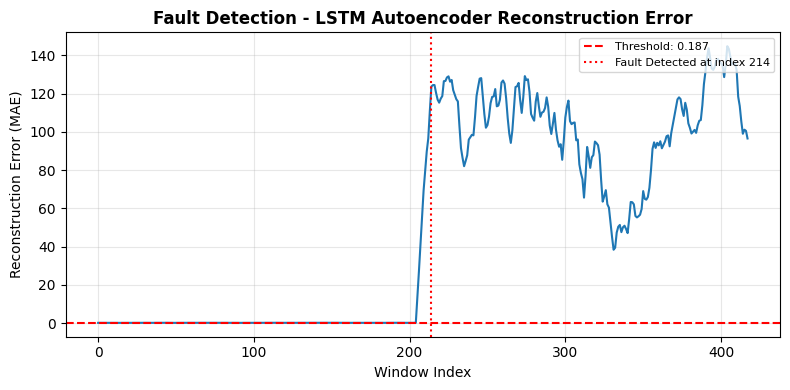

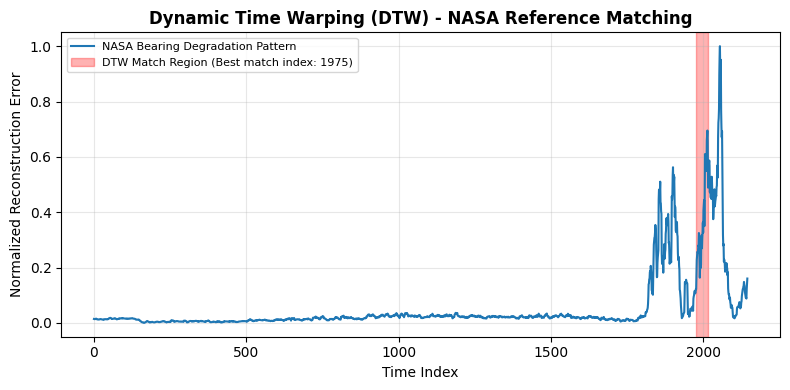

Estimated Time to Failure: 50.64 hours
CNN Predicted Fault Type: Inner


In [ ]:
# =========================
# 1. IMPORTS
# =========================
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from keras.models import Model
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Input

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter


# =========================
# 2. SAFE FUNCTION
# =========================
def safe(x):
    return 0 if (np.isnan(x) or np.isinf(x)) else x


# =========================
# 3. FEATURE EXTRACTION
# =========================
def extract_features(ax, ay, az, fs=1000):

    feats = []

    for axis in [ax, ay, az]:

        mean = safe(np.mean(axis))
        std = safe(np.std(axis))
        rms = safe(np.sqrt(np.mean(axis**2)))
        peak = safe(np.max(np.abs(axis)))
        ptp = safe(np.ptp(axis))
        sk = safe(skew(axis))
        kurt = safe(kurtosis(axis))

        fft_vals = np.abs(fft(axis))[:len(axis)//2]
        freqs = fftfreq(len(axis), 1/fs)[:len(axis)//2]

        centroid = safe(np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-8))
        peak_freq = freqs[np.argmax(fft_vals)] if len(fft_vals) > 0 else 0

        feats.extend([mean, std, rms, peak, ptp, sk, kurt, centroid, peak_freq])

    return feats


# =========================
# 4. LOAD CSV
# =========================
def load_csv(path, label_col='ground_truth'):

    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()

    for c in ['ax','ay','az']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df = df.dropna()

    signal = df[['ax','ay','az']].values.astype(np.float32)
    labels = df[label_col].values if label_col in df.columns else None
    timestamps = pd.to_datetime(df['ts']) if 'ts' in df.columns else None

    return signal, labels, timestamps


# =========================
# 5. WINDOWING
# =========================
def create_windows(signal, win=1024, step=512):

    X = []

    for i in range(0, len(signal)-win, step):
        ax, ay, az = signal[i:i+win].T
        X.append(extract_features(ax, ay, az))

    return np.array(X, dtype=np.float32)


# =========================
# 6. SEQUENCES
# =========================
def create_sequences(data, seq_len=10):

    return np.array([
        data[i:i+seq_len]
        for i in range(len(data)-seq_len)
    ], dtype=np.float32)


# =========================
# 7. LSTM AUTOENCODER (FIXED ARCHITECTURE)
# =========================
def build_model(X):

    inp = Input(shape=(X.shape[1], X.shape[2]))

    # Encoder (MATCH SECOND CODE)
    x = LSTM(32, return_sequences=True)(inp)
    x = LSTM(8, return_sequences=False)(x)

    # Bottleneck
    x = RepeatVector(X.shape[1])(x)

    # Decoder
    x = LSTM(8, return_sequences=True)(x)
    x = LSTM(32, return_sequences=True)(x)

    out = TimeDistributed(Dense(X.shape[2]))(x)

    model = Model(inp, out)
    model.compile(optimizer='adam', loss='mae')

    return model


# =========================
# 8. LOAD DATA
# =========================
normal_signal, _, _ = load_csv("Normal.csv")
test_signal, test_labels, test_timestamps = load_csv("test.csv")


# =========================
# 9. FEATURE BUILDING
# =========================
X_normal = create_windows(normal_signal)
X_test = create_windows(test_signal)


# =========================
# 10. SCALING
# =========================
scaler = MinMaxScaler()
X_normal_scaled = scaler.fit_transform(X_normal)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "scaler.save")


# =========================
# 11. SEQUENCES
# =========================
seq_len = 10

X_train_seq = create_sequences(X_normal_scaled, seq_len)
X_test_seq = create_sequences(X_test_scaled, seq_len)


# =========================
# 12. TRAIN MODEL
# =========================
model = build_model(X_train_seq)

model.fit(
    X_train_seq,
    X_train_seq,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=0  # Silent training
)

model.save("lstm_ae.h5")


# =========================
# 13. LOSS COMPUTATION
# =========================
train_pred = model.predict(X_train_seq, verbose=0)
train_loss = np.mean(np.abs(train_pred - X_train_seq), axis=(1,2))

test_pred = model.predict(X_test_seq, verbose=0)
test_loss = np.mean(np.abs(test_pred - X_test_seq), axis=(1,2))


# =========================
# 14. THRESHOLD
# =========================
threshold = np.mean(train_loss) + 3*np.std(train_loss)


# =========================
# 15. DETECT t2
# =========================
def detect_t2(loss, threshold, K=10):

    count = 0
    t2 = None

    for i, l in enumerate(loss):

        if l > threshold:
            count += 1
            if count >= K:
                t2 = i
                break
        else:
            count = 0

    return t2


t2 = detect_t2(test_loss, threshold)

if t2 is None:
    raise ValueError("No fault detected")


# =========================
# 16. LOAD NASA DATA
# =========================
def load_nasa(data_dir):

    folder = os.path.join(data_dir, "1st_test", "1st_test")
    files = sorted(os.listdir(folder))

    records = []

    for f in files:

        if ".pdf" in f:
            continue

        parts = f.split('.')
        if len(parts) < 6:
            continue

        try:
            ts = pd.Timestamp(
                int(parts[0]), int(parts[1]), int(parts[2]),
                int(parts[3]), int(parts[4]), int(parts[5])
            )

            df = pd.read_csv(os.path.join(folder, f), sep=r"\s+", header=None)
            df = df.iloc[:, :8].dropna()

            x = df[4].values
            y = df[5].values
            z = np.abs(x - y)

            feat = extract_features(x, y, z)
            records.append([ts, feat])

        except:
            continue

    X = np.array([r[1] for r in records])
    t = np.array([r[0] for r in records])

    return X, t


nasa_X, nasa_t = load_nasa("/content/nasa_ims")


# =========================
# 17. NASA LOSS
# =========================
nasa_scaled = scaler.transform(nasa_X)
nasa_seq = create_sequences(nasa_scaled, seq_len)

nasa_pred = model.predict(nasa_seq, verbose=0)
nasa_loss = np.mean(np.abs(nasa_pred - nasa_seq), axis=(1,2))


# =========================
# 18. DTW
# =========================
def dtw_distance(s1, s2):

    n, m = len(s1), len(s2)
    dtw = np.full((n+1, m+1), np.inf)
    dtw[0, 0] = 0

    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw[i, j] = cost + min(
                dtw[i-1, j],
                dtw[i, j-1],
                dtw[i-1, j-1]
            )

    return dtw[n, m]


# =========================
# 19. DTW MAPPING
# =========================
nasa_norm = (nasa_loss - nasa_loss.min()) / (nasa_loss.max() - nasa_loss.min() + 1e-8)
test_norm = (test_loss - test_loss.min()) / (test_loss.max() - test_loss.min() + 1e-8)

window_size = 20

start = max(0, t2 - window_size)
end = min(len(test_norm), t2 + window_size)

test_pattern = test_norm[start:end]

best_match = None
best_dist = float("inf")

for i in range(len(nasa_norm) - len(test_pattern)):

    seg = nasa_norm[i:i+len(test_pattern)]
    dist = dtw_distance(test_pattern, seg)

    if dist < best_dist:
        best_dist = dist
        best_match = i


# =========================
# 20. RUL
# =========================
failure_idx = len(nasa_t) - 1
time_to_failure = nasa_t[failure_idx] - nasa_t[best_match]

hours = time_to_failure / np.timedelta64(1, 'h')


# =========================
# 21. PLOTS (REDUCED SIZE)
# =========================

# Create first figure - Fault Detection (reduced size)
plt.figure(figsize=(8,4))
plt.plot(test_loss, linewidth=1.5)
plt.axhline(threshold, linestyle='--', color='red', linewidth=1.5, label=f'Threshold: {threshold:.3f}')
if t2 is not None:
    plt.axvline(t2, color='red', linewidth=1.5, linestyle=':', label=f'Fault Detected at index {t2}')
plt.title("Fault Detection - LSTM Autoencoder Reconstruction Error", fontsize=12, fontweight='bold')
plt.xlabel("Window Index", fontsize=10)
plt.ylabel("Reconstruction Error (MAE)", fontsize=10)
plt.legend(loc='upper right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Add spacing by printing blank lines
print("\n" * 2)

# Create second figure - DTW Match (reduced size)
plt.figure(figsize=(8,4))
plt.plot(nasa_norm, linewidth=1.5, label='NASA Bearing Degradation Pattern')
plt.axvspan(
    best_match,
    best_match + len(test_pattern),
    color='red',
    alpha=0.3,
    label=f'DTW Match Region (Best match index: {best_match})'
)
plt.title("Dynamic Time Warping (DTW) - NASA Reference Matching", fontsize=12, fontweight='bold')
plt.xlabel("Time Index", fontsize=10)
plt.ylabel("Normalized Reconstruction Error", fontsize=10)
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =========================
# 22. CNN FAULT CLASSIFIER
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

window_size = 50
step_size = 5


# -------------------------
# LOAD RAW SIGNAL
# -------------------------
def load_vibration(file):
    df = pd.read_csv(file, low_memory=False)
    df.columns = df.columns.str.strip()

    for c in ['ax', 'ay', 'az']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df = df.dropna(subset=['ax','ay','az'])
    return df[['ax','ay','az']].values.astype(np.float32)


# -------------------------
# CNN MODEL
# -------------------------
class FaultCNN(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv1d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.fc = nn.Sequential(
            nn.Linear(32 * (window_size // 4), 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


# -------------------------
# LABEL MAP
# -------------------------
label_map = {
    'Normal': 0,
    'Inner': 1,
    'Outer': 2,
    'RE': 3
}

inv_map = {v: k for k, v in label_map.items()}


# -------------------------
# TRAIN OR LOAD CNN
# -------------------------
cnn_model_file = "cnn_fault_model.pth"

cnn_model = FaultCNN(num_classes=4).to(device)

if os.path.exists(cnn_model_file):
    cnn_model.load_state_dict(torch.load(cnn_model_file, map_location=device))
    cnn_model.eval()
else:
    X_cnn, y_cnn = [], []

    fault_files = {
        'Inner': ['inner_L_S1_part1.csv'],
        'Outer': ['outer2__part1_with_ts.csv'],
        'RE': ['RE_part1_with_ts.csv']
    }

    for label, files in fault_files.items():
        for f in files:

            sig = load_vibration(f)

            # normalize per file
            sig = (sig - sig.mean(axis=0)) / (sig.std(axis=0) + 1e-8)

            for i in range(0, len(sig) - window_size, step_size):
                X_cnn.append(sig[i:i+window_size])
                y_cnn.append(label_map[label])

    X_cnn = np.array(X_cnn, dtype=np.float32)
    y_cnn = np.array(y_cnn)

    dataset = TensorDataset(
        torch.from_numpy(X_cnn),
        torch.from_numpy(y_cnn)
    )

    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    cnn_model.train()

    for epoch in range(15):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            loss = criterion(cnn_model(xb), yb)
            loss.backward()
            optimizer.step()

    torch.save(cnn_model.state_dict(), cnn_model_file)


# =========================
# 23. CNN INFERENCE ON TEST REGION
# =========================

if t2 is not None:

    sig_test = load_vibration("test.csv")

    sig_test = (sig_test - sig_test.mean(axis=0)) / (sig_test.std(axis=0) + 1e-8)

    # focus around fault region
    start = max(0, t2 * step_size - window_size * 10)
    end   = min(len(sig_test), t2 * step_size + window_size * 10)

    region = sig_test[start:end]

    X_test_cnn = []

    for i in range(0, len(region) - window_size, step_size):
        X_test_cnn.append(region[i:i+window_size])

    if len(X_test_cnn) > 0:
        X_test_cnn = np.array(X_test_cnn, dtype=np.float32)

        cnn_model.eval()

        with torch.no_grad():
            tensor = torch.from_numpy(X_test_cnn).float().to(device)
            outputs = cnn_model(tensor)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()

        final_label = Counter([inv_map[p] for p in preds]).most_common(1)[0][0]

        # PRINT BOTH LINES AT THE END
        print(f"Estimated Time to Failure: {float(hours):.2f} hours")
        print(f"CNN Predicted Fault Type: {final_label}")

else:
    print("CNN skipped because no fault detected (t2 is None)")

NASA IMS Bearing Dataset-Set1-Bearing3-Innerrace Defect

Feature shape: (2156, 27)
Sequence shape: (2146, 10, 27)
Train: (536, 10, 27) Test: (1610, 10, 27)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 10, 27)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 32)         │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 8)              │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 8)          │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10, 32)         │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 27)         │           891 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,675 (61.23 KB)

 Trainable params: 15,675 (61.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.3594 - val_loss: 0.6465
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.2883 - val_loss: 0.5742
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.2326 - val_loss: 0.5043
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1958 - val_loss: 0.4513
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1691 - val_loss: 0.4333
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1475 - val_loss: 0.4184
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1344 - val_loss: 0.4091
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.1221 - val_loss: 0.4043
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1073 - val_loss: 0.4001
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0951 - val_loss: 0.3965
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0881 - val_loss: 0.3951
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Loss range: 0.054145 3.698611
Threshold: 0.104592
First warning (t1): 2003-10-29 14:59:46
Confirmed fault (t2): 2003-11-08 23:31:44
Lead time: 10 days 08:31:58

TIMING ANALYSIS
Hours from confirmed fault (t2) to failure: 408.14 (17.01 days)


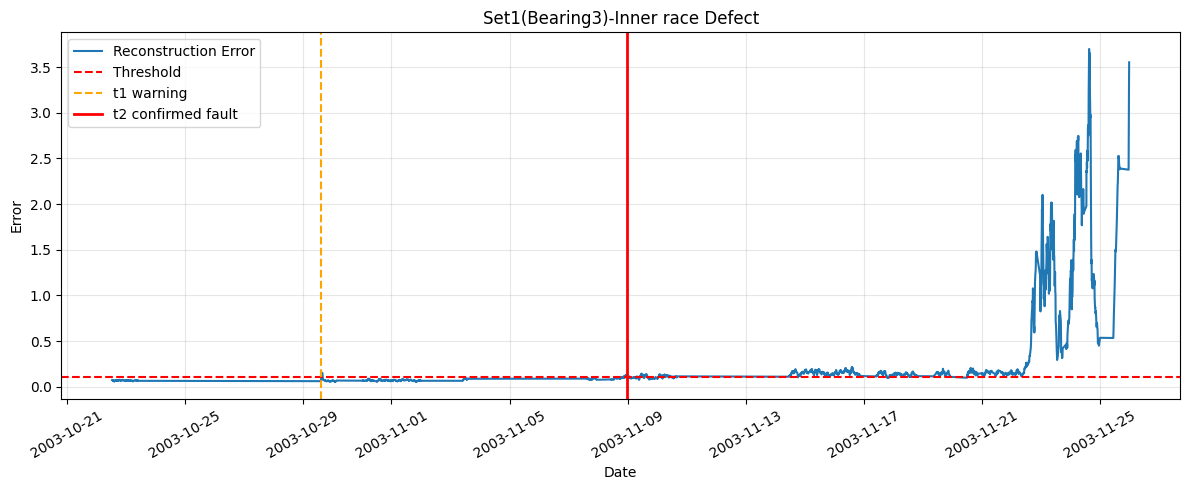

In [ ]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import MinMaxScaler

from keras.models import Model
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Input


# =========================
# SAFE FUNCTION
# =========================
def safe(x):
    return 0 if (np.isnan(x) or np.isinf(x)) else x


# =========================
# FEATURE EXTRACTION
# =========================
def extract_features(axis, fs=20000):

    axis = np.nan_to_num(axis)

    mean = safe(np.mean(axis))
    std = safe(np.std(axis))
    rms = safe(np.sqrt(np.mean(axis**2)))
    peak = safe(np.max(np.abs(axis)))
    ptp = safe(np.ptp(axis))
    sk = safe(skew(axis))
    kurt = safe(kurtosis(axis))

    fft_vals = np.abs(fft(axis))[:len(axis)//2]
    freqs = fftfreq(len(axis), 1/fs)[:len(axis)//2]

    if np.sum(fft_vals) == 0:
        centroid = 0
    else:
        centroid = safe(np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-8))

    peak_freq = safe(freqs[np.argmax(fft_vals)]) if len(fft_vals) > 0 else 0

    return [
        mean, std, rms, peak, ptp,
        sk, kurt, centroid, peak_freq
    ]


# =========================
# LOAD NASA IMS DATA
# =========================
def load_nasa_single_bearing(data_dir, dataset='1st_test'):

    folder = os.path.join(data_dir, dataset, dataset)
    if not os.path.exists(folder):
        folder = os.path.join(data_dir, dataset)

    files = sorted(os.listdir(folder))
    records = []

    for fname in files:
        if fname.endswith(".pdf"):
            continue

        try:
            parts = fname.split('.')
            if len(parts) < 6:
                continue

            timestamp = pd.Timestamp(
                int(parts[0]), int(parts[1]), int(parts[2]),
                int(parts[3]), int(parts[4]), int(parts[5])
            )

            data = pd.read_csv(os.path.join(folder, fname), sep=r'\s+', header=None)

            if data.shape[1] < 8:
                continue

            data = data.iloc[:, :8].dropna()

            x = data[4].values
            y = data[5].values
            z = np.abs(x - y)

            records.append([timestamp, x, y, z])

        except:
            continue

    return records


# =========================
# BUILD FEATURE DATASET
# =========================
def build_dataset(records):

    X, timestamps = [], []

    for t, x, y, z in records:

        feat_vector = []

        for axis in [x, y, z]:
            feat_vector.extend(extract_features(axis))

        X.append(feat_vector)
        timestamps.append(t)

    return np.array(X, dtype=np.float32), np.array(timestamps)


# =========================
# LOAD DATA
# =========================
data_dir = "/content/nasa_ims"

records = load_nasa_single_bearing(data_dir, "1st_test")
X, timestamps = build_dataset(records)

print("Feature shape:", X.shape)


# =========================
# SCALING
# =========================
train_size_raw = int(0.25 * len(X))

scaler = MinMaxScaler()
scaler.fit(X[:train_size_raw])

X_scaled = scaler.transform(X)

joblib.dump(scaler, "nasa_27feat_scaler.save")


# =========================
# SEQUENCES
# =========================
def create_sequences(data, seq_len=10):
    return np.array([data[i:i+seq_len] for i in range(len(data)-seq_len)])

seq_len = 10
X_seq = create_sequences(X_scaled, seq_len)

print("Sequence shape:", X_seq.shape)


# =========================
# SPLIT
# =========================
train_split = int(0.25 * len(X_seq))

X_train = X_seq[:train_split]
X_test = X_seq[train_split:]

print("Train:", X_train.shape, "Test:", X_test.shape)


# =========================
# MODEL
# =========================
inp = Input(shape=(seq_len, 27))

x = LSTM(32, return_sequences=True)(inp)
x = LSTM(8, return_sequences=False)(x)

x = RepeatVector(seq_len)(x)

x = LSTM(8, return_sequences=True)(x)
x = LSTM(32, return_sequences=True)(x)

out = TimeDistributed(Dense(27))(x)

model = Model(inp, out)
model.compile(optimizer='adam', loss='mae')

model.summary()


# =========================
# TRAIN
# =========================
model.fit(
    X_train, X_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, X_test)
)

model.save("nasa_lstm_27feat.h5")


# =========================
# LOSS
# =========================
X_pred = model.predict(X_seq)
loss = np.mean(np.abs(X_pred - X_seq), axis=(1,2))


# =========================
# THRESHOLD
# =========================
train_loss = loss[:train_split]
threshold = np.mean(train_loss) + 3*np.std(train_loss)

np.save("nasa_threshold_27feat.npy", threshold)


# =========================
# FAULT DETECTION
# =========================
def detect_fault(loss, threshold, K=10):

    flags = loss > threshold
    count = 0
    t1, t2 = None, None

    for i, f in enumerate(flags):
        if f:
            if t1 is None:
                t1 = i
            count += 1
            if count >= K:
                t2 = i
                break
        else:
            count = 0

    return t1, t2


t1, t2 = detect_fault(loss, threshold, K=10)


# =========================
# TIME MAPPING
# =========================
ts_seq = timestamps[seq_len:]
end_time = ts_seq[-1]

t1_time = ts_seq[t1] if t1 is not None else None
t2_time = ts_seq[t2] if t2 is not None else None


# =========================
# OUTPUT
# =========================
print(f"Loss range: {loss.min():.6f} {loss.max():.6f}")
print(f"Threshold: {threshold:.6f}")

if t1_time is not None:
    print(f"First warning (t1): {t1_time}")

if t2_time is not None:
    print(f"Confirmed fault (t2): {t2_time}")

    if t1_time is not None:
        print(f"Lead time: {t2_time - t1_time}")


print("\nTIMING ANALYSIS")

if t2_time is not None:
    hours_end = (end_time - t2_time) / np.timedelta64(1, 'h')
    days_end = hours_end / 24

    print(f"Hours from confirmed fault (t2) to failure: {float(hours_end):.2f} ({float(days_end):.2f} days)")


# =========================
# PLOT (MATCHED COLOR SCHEME)
# =========================
# =========================
# PLOT (TIMESTAMP X-AXIS)
# =========================
plt.figure(figsize=(12,5))

plt.plot(ts_seq, loss, label="Reconstruction Error")

# Threshold (red dashed)
plt.axhline(threshold, color='red', linestyle='--', label="Threshold")

# t1 (orange dashed)
if t1 is not None:
    plt.axvline(t1_time, color='orange', linestyle='--', label="t1 warning")

# t2 (solid red)
if t2 is not None:
    plt.axvline(t2_time, color='red', linewidth=2, label="t2 confirmed fault")

plt.legend()
plt.title("Set1(Bearing3)-Inner race Defect")
plt.xlabel("Date")
plt.ylabel("Error")
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NASA IMS Bearing Dataset-Set1-Bearing4-RE Defect

Feature shape: (2156, 27)
Sequence shape: (2146, 10, 27)
Train: (536, 10, 27) Test: (1610, 10, 27)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 10, 27)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_12 (LSTM)                  │ (None, 10, 32)         │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 8)              │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 10, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 10, 8)          │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 10, 32)         │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 10, 27)         │           891 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,675 (61.23 KB)

 Trainable params: 15,675 (61.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - loss: 0.3738 - val_loss: 0.5754
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.2661 - val_loss: 0.4999
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.2040 - val_loss: 0.4557
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 0.1674 - val_loss: 0.4292
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.1411 - val_loss: 0.4112
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.1229 - val_loss: 0.4002
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - loss: 0.1105 - val_loss: 0.3928
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.1008 - val_loss: 0.3855
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.0928 - val_loss: 0.3810
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0857 - val_loss: 0.3774
Epoch 11/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.0795 - val_loss: 0.3727
Epoch 12/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0

68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step
Loss range: 0.045711 2.740273
Threshold: 0.097510
First warning (t1): 2003-10-22 14:14:13
Confirmed fault (t2): 2003-11-07 17:31:44
Lead time: 16 days 03:17:31

TIMING ANALYSIS
Hours from confirmed fault (t2) to failure: 438.14 (18.26 days)


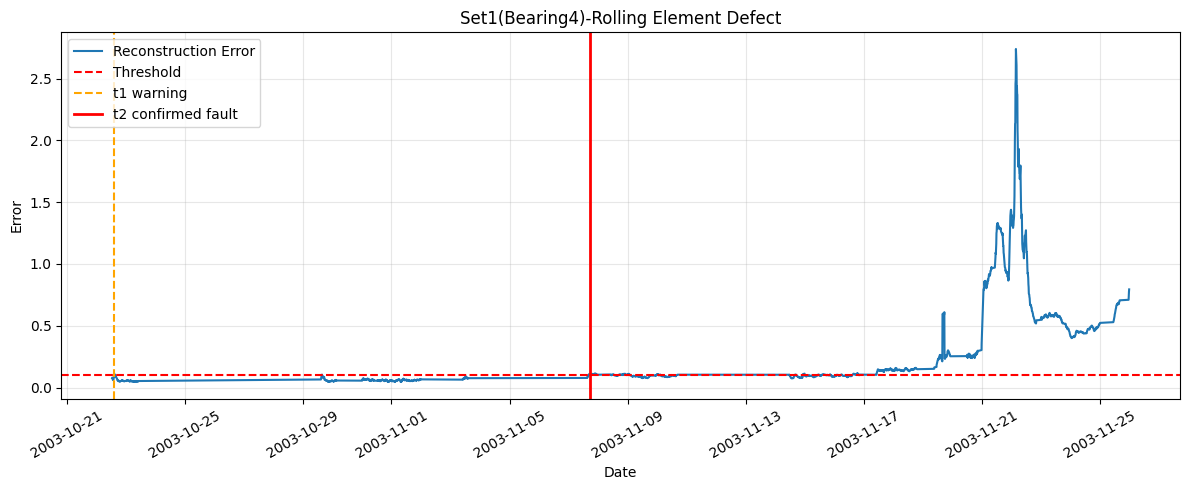

In [ ]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import MinMaxScaler

from keras.models import Model
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Input


def safe(x):
    return 0 if (np.isnan(x) or np.isinf(x)) else x


def extract_features(axis, fs=20000):
    axis = np.nan_to_num(axis)

    mean = safe(np.mean(axis))
    std = safe(np.std(axis))
    rms = safe(np.sqrt(np.mean(axis**2)))
    peak = safe(np.max(np.abs(axis)))
    ptp = safe(np.ptp(axis))
    sk = safe(skew(axis))
    kurt = safe(kurtosis(axis))

    fft_vals = np.abs(fft(axis))[:len(axis)//2]
    freqs = fftfreq(len(axis), 1/fs)[:len(axis)//2]

    centroid = 0 if np.sum(fft_vals) == 0 else safe(
        np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-8)
    )

    peak_freq = safe(freqs[np.argmax(fft_vals)]) if len(fft_vals) > 0 else 0

    return [
        mean, std, rms, peak, ptp,
        sk, kurt, centroid, peak_freq
    ]


def load_nasa_single_bearing(data_dir, dataset='1st_test', bearing_id=4):

    folder = os.path.join(data_dir, dataset, dataset)
    if not os.path.exists(folder):
        folder = os.path.join(data_dir, dataset)

    files = sorted(os.listdir(folder))
    records = []

    bearing_map = {1:(0,1), 2:(2,3), 3:(4,5), 4:(6,7)}
    col_x, col_y = bearing_map[bearing_id]

    for fname in files:
        if fname.endswith(".pdf"):
            continue

        try:
            parts = fname.split('.')
            if len(parts) < 6:
                continue

            timestamp = pd.Timestamp(
                int(parts[0]), int(parts[1]), int(parts[2]),
                int(parts[3]), int(parts[4]), int(parts[5])
            )

            data = pd.read_csv(os.path.join(folder, fname), sep=r'\s+', header=None)

            if data.shape[1] <= col_y:
                continue

            data = data.iloc[:, :8].dropna()

            x = data[col_x].values
            y = data[col_y].values
            z = np.abs(x - y)

            records.append([timestamp, x, y, z])

        except:
            continue

    return records


def build_dataset(records):
    X, timestamps = [], []

    for t, x, y, z in records:
        feat_vector = []
        for axis in [x, y, z]:
            feat_vector.extend(extract_features(axis))
        X.append(feat_vector)
        timestamps.append(t)

    return np.array(X, dtype=np.float32), np.array(timestamps)


# =========================
# LOAD DATA
# =========================
data_dir = "/content/nasa_ims"

records = load_nasa_single_bearing(data_dir, "1st_test", bearing_id=4)
X, timestamps = build_dataset(records)

print("Feature shape:", X.shape)

# =========================
# SCALING
# =========================
train_size_raw = int(0.25 * len(X))
scaler = MinMaxScaler()
scaler.fit(X[:train_size_raw])

X_scaled = scaler.transform(X)

joblib.dump(scaler, "nasa_27feat_scaler.save")


# =========================
# SEQUENCES
# =========================
seq_len = 10
X_seq = np.array([X_scaled[i:i+seq_len] for i in range(len(X_scaled)-seq_len)])

print("Sequence shape:", X_seq.shape)

# =========================
# SPLIT
# =========================
train_split = int(0.25 * len(X_seq))

X_train = X_seq[:train_split]
X_test = X_seq[train_split:]

print("Train:", X_train.shape, "Test:", X_test.shape)


# =========================
# MODEL
# =========================
inp = Input(shape=(seq_len, 27))

x = LSTM(32, return_sequences=True)(inp)
x = LSTM(8, return_sequences=False)(x)

x = RepeatVector(seq_len)(x)

x = LSTM(8, return_sequences=True)(x)
x = LSTM(32, return_sequences=True)(x)

out = TimeDistributed(Dense(27))(x)

model = Model(inp, out)
model.compile(optimizer='adam', loss='mae')

model.summary()


# =========================
# TRAIN
# =========================
model.fit(
    X_train, X_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, X_test)
)

model.save("nasa_lstm_27feat.h5")


# =========================
# LOSS
# =========================
X_pred = model.predict(X_seq)
loss = np.mean(np.abs(X_pred - X_seq), axis=(1,2))


# =========================
# THRESHOLD
# =========================
train_loss = loss[:train_split]
threshold = np.mean(train_loss) + 3*np.std(train_loss)

np.save("nasa_threshold_27feat.npy", threshold)


# =========================
# FAULT DETECTION
# =========================
def detect_fault(loss, threshold, K=10):
    flags = loss > threshold
    count = 0
    t1, t2 = None, None

    for i, f in enumerate(flags):
        if f:
            if t1 is None:
                t1 = i
            count += 1
            if count >= K:
                t2 = i
                break
        else:
            count = 0

    return t1, t2


t1, t2 = detect_fault(loss, threshold, K=10)


# =========================
# TIME MAPPING
# =========================
ts_seq = timestamps[seq_len:]
end_time = ts_seq[-1]

t1_time = ts_seq[t1] if t1 is not None else None
t2_time = ts_seq[t2] if t2 is not None else None


# =========================
# OUTPUT (FIXED FORMAT)
# =========================
print(f"Loss range: {loss.min():.6f} {loss.max():.6f}")
print(f"Threshold: {threshold:.6f}")

if t1_time is not None:
    print(f"First warning (t1): {t1_time}")

if t2_time is not None:
    print(f"Confirmed fault (t2): {t2_time}")

    if t1_time is not None:
        print(f"Lead time: {t2_time - t1_time}")


print("\nTIMING ANALYSIS")

if t2_time is not None:
    hours_end = (end_time - t2_time) / np.timedelta64(1, 'h')
    days_end = hours_end / 24

    print(f"Hours from confirmed fault (t2) to failure: {float(hours_end):.2f} ({float(days_end):.2f} days)")


# =========================
# PLOT
# =========================
# =========================
# PLOT (TIMESTAMP X-AXIS)
# =========================
plt.figure(figsize=(12,5))

plt.plot(ts_seq, loss, label="Reconstruction Error")

# Threshold (red dashed)
plt.axhline(threshold, color='red', linestyle='--', label="Threshold")

# t1 (orange dashed)
if t1 is not None:
    plt.axvline(t1_time, color='orange', linestyle='--', label="t1 warning")

# t2 (solid red)
if t2 is not None:
    plt.axvline(t2_time, color='red', linewidth=2, label="t2 confirmed fault")

plt.legend()
plt.title("Set1(Bearing4)-Rolling Element Defect")
plt.xlabel("Date")
plt.ylabel("Error")
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.show()

NASA IMS Bearing Dataset-Set2-Bearing1-Outerrace Defect

Feature shape: (984, 27)
Sequence shape: (974, 10, 27)
Train: (243, 10, 27) Test: (731, 10, 27)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 10, 27)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 10, 32)         │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 8)              │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_4 (RepeatVector)  │ (None, 10, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 10, 8)          │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 10, 32)         │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 10, 27)         │           891 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,675 (61.23 KB)

 Trainable params: 15,675 (61.23 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - loss: 0.3066 - val_loss: 26.8807
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.2878 - val_loss: 26.8589
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.2566 - val_loss: 26.8239
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.2158 - val_loss: 26.7753
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1862 - val_loss: 26.7440
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.1600 - val_loss: 26.7302
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1386 - val_loss: 26.7137
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.1225 - val_loss: 26.7014
Epoch 9/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1093 - val_loss: 26.6896
Epoch 10/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1011 - val_loss: 26.6846
Epoch 11/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0958 - val_loss: 26.6785
Epoch 12/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0916 - val_lo

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step
Loss range: 0.050795477 132.3093
Threshold: 0.10894868
Loss range: 0.050795 132.309296
Threshold: 0.108949
First warning (t1): 2004-02-12 12:12:39
Confirmed fault (t2): 2004-02-16 05:12:39
Lead time: 3 days 17:00:00

TIMING ANALYSIS
Hours from confirmed fault (t2) to failure: 73.17 (3.05 days)


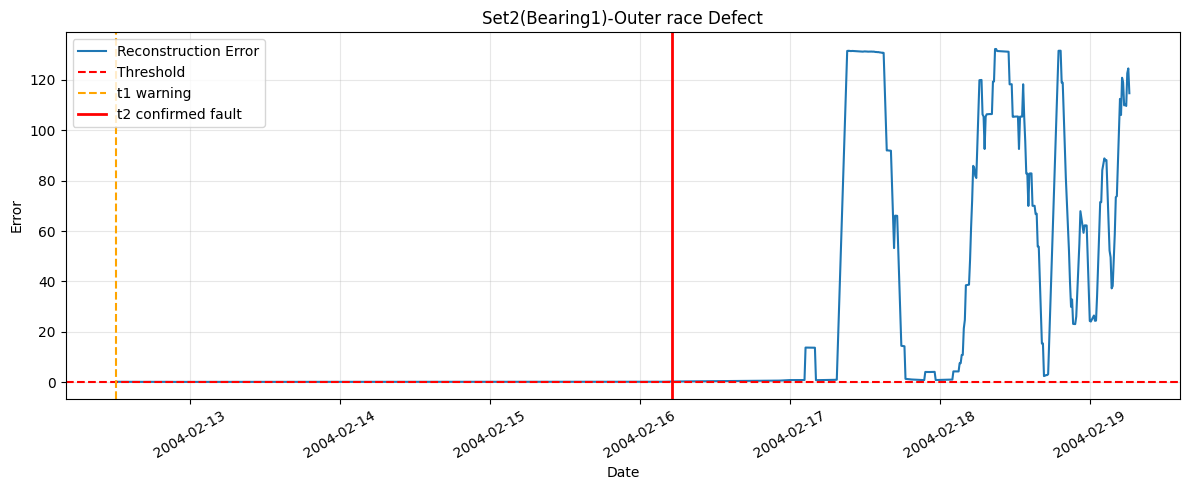

In [ ]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import MinMaxScaler

from keras.models import Model
from keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Input


# =========================
# SAFE FUNCTION
# =========================
def safe(x):
    return 0 if (np.isnan(x) or np.isinf(x)) else x


# =========================
# FEATURE EXTRACTION
# =========================
def extract_features(axis, fs=20000):

    axis = np.nan_to_num(axis)

    mean = safe(np.mean(axis))
    std = safe(np.std(axis))
    rms = safe(np.sqrt(np.mean(axis**2)))
    peak = safe(np.max(np.abs(axis)))
    ptp = safe(np.ptp(axis))
    sk = safe(skew(axis))
    kurt = safe(kurtosis(axis))

    fft_vals = np.abs(fft(axis))[:len(axis)//2]
    freqs = fftfreq(len(axis), 1/fs)[:len(axis)//2]

    if np.sum(fft_vals) == 0:
        centroid = 0
    else:
        centroid = safe(np.sum(freqs * fft_vals) / (np.sum(fft_vals) + 1e-8))

    peak_freq = safe(freqs[np.argmax(fft_vals)]) if len(fft_vals) > 0 else 0

    return [
        mean, std, rms, peak, ptp,
        sk, kurt, centroid, peak_freq
    ]


# =========================
# LOAD NASA IMS DATA (UPDATED FOR ALL SETS)
# =========================
def load_nasa_single_bearing(data_dir, dataset='2nd_test', bearing_id=1):

    folder = os.path.join(data_dir, dataset, dataset)
    if not os.path.exists(folder):
        folder = os.path.join(data_dir, dataset)

    files = sorted(os.listdir(folder))
    records = []

    # Different mapping for Set 1 vs Set 2/3
    if dataset == '1st_test':
        bearing_map = {
            1: (0, 1),
            2: (2, 3),
            3: (4, 5),
            4: (6, 7)
        }
    else:
        # Set 2 and 3 → single channel per bearing
        bearing_map = {
            1: (0, None),
            2: (1, None),
            3: (2, None),
            4: (3, None)
        }

    if bearing_id not in bearing_map:
        raise ValueError("Bearing ID must be 1, 2, 3, or 4")

    col_x, col_y = bearing_map[bearing_id]

    for fname in files:
        if fname.endswith(".pdf"):
            continue

        try:
            parts = fname.split('.')
            if len(parts) < 6:
                continue

            timestamp = pd.Timestamp(
                int(parts[0]), int(parts[1]), int(parts[2]),
                int(parts[3]), int(parts[4]), int(parts[5])
            )

            data = pd.read_csv(
                os.path.join(folder, fname),
                sep=r'\s+',
                header=None
            )

            if data.shape[1] <= col_x:
                continue

            data = data.dropna()

            # ✅ Bearing 1 (Set 2 → single channel)
            x = data[col_x].values

            if col_y is not None:
                y = data[col_y].values
                z = np.abs(x - y)
            else:
                y = x.copy()
                z = np.zeros_like(x)

            records.append([timestamp, x, y, z])

        except:
            continue

    return records


# =========================
# BUILD FEATURE DATASET
# =========================
def build_dataset(records):

    X, timestamps = [], []

    for t, x, y, z in records:

        feat_vector = []

        for axis in [x, y, z]:
            feat_vector.extend(extract_features(axis))

        X.append(feat_vector)
        timestamps.append(t)

    return np.array(X, dtype=np.float32), np.array(timestamps)


# =========================
# LOAD DATA (Bearing 1 – Set 2)
# =========================
data_dir = "/content/nasa_ims"

records = load_nasa_single_bearing(data_dir, "2nd_test", bearing_id=1)
X, timestamps = build_dataset(records)

print("Feature shape:", X.shape)


# =========================
# TIME-AWARE SPLIT
# =========================
train_size_raw = int(0.25 * len(X))

scaler = MinMaxScaler()
scaler.fit(X[:train_size_raw])

X_scaled = scaler.transform(X)

joblib.dump(scaler, "nasa_27feat_scaler.save")


# =========================
# CREATE SEQUENCES
# =========================
def create_sequences(data, seq_len=10):
    Xs = []
    for i in range(len(data) - seq_len):
        Xs.append(data[i:i+seq_len])
    return np.array(Xs)

seq_len = 10
X_seq = create_sequences(X_scaled, seq_len)

print("Sequence shape:", X_seq.shape)


# =========================
# TRAIN / TEST SPLIT
# =========================
train_split = int(0.25 * len(X_seq))

X_train = X_seq[:train_split]
X_test = X_seq[train_split:]

print("Train:", X_train.shape, "Test:", X_test.shape)


# =========================
# LSTM AUTOENCODER
# =========================
inp = Input(shape=(seq_len, 27))

x = LSTM(32, return_sequences=True)(inp)
x = LSTM(8, return_sequences=False)(x)

x = RepeatVector(seq_len)(x)

x = LSTM(8, return_sequences=True)(x)
x = LSTM(32, return_sequences=True)(x)

out = TimeDistributed(Dense(27))(x)

model = Model(inp, out)
model.compile(optimizer='adam', loss='mae')

model.summary()


# =========================
# TRAIN MODEL
# =========================
model.fit(
    X_train, X_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, X_test)
)

model.save("nasa_lstm_27feat.h5")


# =========================
# PREDICTION + LOSS
# =========================
X_pred = model.predict(X_seq)

loss = np.mean(np.abs(X_pred - X_seq), axis=(1,2))

print("Loss range:", loss.min(), loss.max())


# =========================
# THRESHOLD
# =========================
train_loss = loss[:train_split]
threshold = np.mean(train_loss) + 3*np.std(train_loss)

np.save("nasa_threshold_27feat.npy", threshold)

print("Threshold:", threshold)


# =========================
# FAULT DETECTION
# =========================
def detect_fault(loss, threshold, K=10):

    flags = loss > threshold
    count = 0
    t1, t2 = None, None

    for i, f in enumerate(flags):

        if f:
            if t1 is None:
                t1 = i
            count += 1
            if count >= K:
                t2 = i
                break
        else:
            count = 0

    return t1, t2


t1, t2 = detect_fault(loss, threshold, K=10)


# =========================
# TIME MAPPING
# =========================
# =========================
# TIME MAPPING + FINAL OUTPUT (CLEAN FORMAT)
# =========================
ts_seq = timestamps[seq_len:]
failure_time = ts_seq[-1]

print(f"Loss range: {loss.min():.6f} {loss.max():.6f}")
print(f"Threshold: {threshold:.6f}")

# t1
if t1 is not None:
    t1_time = ts_seq[t1]
    print(f"First warning (t1): {t1_time}")

# t2 + timing
if t2 is not None:
    t2_time = ts_seq[t2]
    print(f"Confirmed fault (t2): {t2_time}")

    if t1 is not None:
        lead_time = t2_time - t1_time
        print(f"Lead time: {lead_time}")

    # ✅ FINAL REQUIRED OUTPUT
    hours = (failure_time - t2_time) / np.timedelta64(1, 'h')
    days = hours / 24

    print("\nTIMING ANALYSIS")
    print(f"Hours from confirmed fault (t2) to failure: {float(hours):.2f} ({float(days):.2f} days)")



# =========================
# PLOT
# =========================
plt.figure(figsize=(12,5))

plt.plot(ts_seq, loss, label="Reconstruction Error")

# Threshold (red dashed)
plt.axhline(threshold, color='red', linestyle='--', label="Threshold")

# t1 (orange dashed)
if t1 is not None:
    plt.axvline(t1_time, color='orange', linestyle='--', label="t1 warning")

# t2 (solid red)
if t2 is not None:
    plt.axvline(t2_time, color='red', linewidth=2, label="t2 confirmed fault")

plt.legend()
plt.title("Set2(Bearing1)-Outer race Defect")
plt.xlabel("Date")
plt.ylabel("Error")
plt.xticks(rotation=30)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.show()

Real Time


In [ ]:
# =========================
# 1. IMPORTS
# =========================
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import f1_score
from scipy import stats
from scipy.fft import fft, fftfreq
import joblib

import tensorflow as tf
from keras.layers import Input, Dense, LSTM, TimeDistributed, RepeatVector
from keras.models import Model, load_model
from tensorflow.keras import mixed_precision

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import random
from collections import Counter
import matplotlib.pyplot as plt

# =========================
# 2. SEEDING & DEVICE
# =========================
np.random.seed(10)
tf.random.set_seed(10)
torch.manual_seed(42)
random.seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mixed_precision.set_global_policy('mixed_float16')

# =========================
# 3. SAFE CSV LOADER
# =========================
def load_clean_csv(path, label_col='ground_truth'):
    df = pd.read_csv(path, low_memory=False)
    df.columns = df.columns.str.strip()
    for col in ['ax','ay','az']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    if label_col in df.columns:
        df[label_col] = pd.to_numeric(df[label_col], errors='coerce')
    df = df.dropna()
    df = df[(df[['ax','ay','az']].abs() < 1e6).all(axis=1)]
    signal = df[['ax','ay','az']].values.astype(np.float32)
    labels = df[label_col].values.astype(int) if label_col in df.columns else np.zeros(len(signal))
    # Extract timestamps if available
    timestamps = pd.to_datetime(df['ts']) if 'ts' in df.columns else None
    return signal, labels, timestamps

# =========================
# 4. FEATURE EXTRACTION
# =========================
def safe(x): return 0 if (np.isnan(x) or np.isinf(x)) else x

def extract_features(ax, ay, az, fs=1000):
    feats = []
    for axis in [ax, ay, az]:
        mean = safe(np.mean(axis))
        std = safe(np.std(axis))
        rms = safe(np.sqrt(np.mean(axis**2)))
        peak = safe(np.max(np.abs(axis)))
        ptp = safe(np.ptp(axis))
        skew = safe(stats.skew(axis))
        kurt = safe(stats.kurtosis(axis))
        fft_vals = np.abs(fft(axis))[:len(axis)//2]
        freqs = fftfreq(len(axis), 1/fs)[:len(axis)//2]
        centroid = safe(np.sum(freqs * fft_vals) / (np.sum(fft_vals)+1e-8))
        peak_freq = freqs[np.argmax(fft_vals)] if len(fft_vals) > 0 else 0
        feats.extend([mean,std,rms,peak,ptp,skew,kurt,centroid,peak_freq])
    return feats

# =========================
# 5. WINDOWING
# =========================
def create_windows(signal, labels, win=1024, step=512):
    X, y = [], []
    for i in range(0, len(signal)-win, step):
        ax, ay, az = signal[i:i+win].T
        X.append(extract_features(ax, ay, az))
        y.append(np.max(labels[i:i+win]))
    return np.array(X, dtype=np.float32), np.array(y)

# =========================
# 6. SEQUENCE CREATION
# =========================
seq_len = 10
def create_sequences(data, seq_len):
    Xs = []
    for i in range(len(data)-seq_len):
        Xs.append(data[i:i+seq_len])
    return np.array(Xs, dtype=np.float32)

# =========================
# 7. LSTM AUTOENCODER MODEL
# =========================
def build_lstm_ae(X):
    inp = Input(shape=(X.shape[1], X.shape[2]))
    x = LSTM(32, return_sequences=True)(inp)
    x = LSTM(8)(x)
    x = RepeatVector(X.shape[1])(x)
    x = LSTM(8, return_sequences=True)(x)
    x = LSTM(32, return_sequences=True)(x)
    out = TimeDistributed(Dense(X.shape[2]))(x)
    return Model(inp, out)

# =========================
# 8. LOAD / TRAIN LSTM AE
# =========================
ae_model_file = 'lstm_autoencoder_model.h5'
scaler_file = 'scaler.save'
threshold_file = 'ae_threshold.npy'

signal_train, labels_train, timestamps_train = load_clean_csv("Normal.csv")
signal_test,  labels_test,  timestamps_test  = load_clean_csv("test.csv")

X_train_feat, y_train_feat = create_windows(signal_train, labels_train)
X_test_feat,  y_test_feat  = create_windows(signal_test,  labels_test)

X_train_feat = np.nan_to_num(X_train_feat)
X_test_feat  = np.nan_to_num(X_test_feat)

train_size = int(0.5 * len(X_train_feat))
X_train = X_train_feat[:train_size]

if os.path.exists(ae_model_file) and os.path.exists(scaler_file) and os.path.exists(threshold_file):
    model = load_model(ae_model_file, custom_objects={'mae': tf.keras.losses.MeanAbsoluteError})
    scaler = joblib.load(scaler_file)
    threshold = np.load(threshold_file)
else:
    scaler = MinMaxScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_train_seq = create_sequences(X_train_scaled, seq_len)

    model = build_lstm_ae(X_train_seq)
    model.compile(optimizer='adam', loss='mae')
    noise = np.random.normal(0, 0.02, X_train_seq.shape).astype(np.float32)
    model.fit(X_train_seq + noise, X_train_seq, epochs=20, batch_size=32)

    model.save(ae_model_file)
    joblib.dump(scaler, scaler_file)
    train_pred = model.predict(X_train_seq)
    train_loss = np.mean(np.abs(train_pred - X_train_seq), axis=(1,2))
    threshold = 0.40
    np.save(threshold_file, threshold)

# =========================
# 9. TEST LSTM AE
# =========================
X_test_scaled = scaler.transform(X_test_feat)
X_test_seq = create_sequences(X_test_scaled, seq_len)

test_pred = model.predict(X_test_seq)
test_loss = np.mean(np.abs(test_pred - X_test_seq), axis=(1,2))
anomaly_flags = (test_loss > threshold).astype(int)
ae_output_array = np.array(['Fault' if f==1 else 'Normal' for f in anomaly_flags])

# =========================
# 10. K-CONSECUTIVE DETECTION
# =========================
K = 10
win  = 1024
step = 512

def detect_fault_consecutive(errors, threshold, K=10):
    preds = (errors > threshold).astype(int)
    count = 0
    t1, t2 = None, None
    for i, p in enumerate(preds):
        if p == 1:
            if t1 is None:
                t1 = i
            count += 1
            if count == K:
                t2 = i
                break
        else:
            count = 0
    return preds, t1, t2

preds, t1, t2 = detect_fault_consecutive(test_loss, threshold, K)

# =========================
# 10B. TIMESTAMP MAPPING
# =========================
t1_str = None
t2_str = None
advance_warning_ms = None

if timestamps_test is not None and t1 is not None:
    # Map window index to the last sample of that window in the original signal
    t1_sample = t1 * step + win
    t2_sample = t2 * step + win if t2 is not None else None

    # Clamp to valid range
    t1_sample = min(t1_sample, len(timestamps_test) - 1)

    t1_ts = timestamps_test.iloc[t1_sample]
    t1_str = t1_ts.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]

    if t2_sample is not None:
        t2_sample = min(t2_sample, len(timestamps_test) - 1)
        t2_ts = timestamps_test.iloc[t2_sample]
        t2_str = t2_ts.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]
        advance_warning_ms = (t2_ts - t1_ts).total_seconds() * 1000

    print(f"First anomaly detected at : {t1_str}")
    if t2_str:
        print(f"Fault confirmed at        : {t2_str}")
        print(f"Advance warning           : {advance_warning_ms:.0f} ms")

# =========================
# 11. AE RECONSTRUCTION ERROR PLOT
# =========================
plt.figure(figsize=(12,5))
plt.plot(test_loss, label="Reconstruction Error")
plt.axhline(threshold, linestyle='--', color='red', label="Threshold")
if t1 is not None:
    plt.axvline(t1, color='orange', linestyle='--', label=f"First Detection")
if t2 is not None:
    plt.axvline(t2, color='red', linewidth=2, label=f"Confirmed Fault ({K} consecutive)")
plt.title("AE Reconstruction Error with K-Consecutive Fault Detection")
plt.xlabel("Window Index")
plt.ylabel("MAE")
plt.legend()
plt.tight_layout()
ae_error_image_path = "ae_reconstruction_error.png"
plt.savefig(ae_error_image_path)
plt.close()

# =========================
# 12. RAW TEST SIGNAL PLOT
# =========================
plt.figure(figsize=(12,5))
plt.plot(signal_test[:,0], label='ax')
plt.plot(signal_test[:,1], label='ay')
plt.plot(signal_test[:,2], label='az')
plt.title("Raw Test Signals")
plt.xlabel("Time Index")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
raw_signal_image_path = "raw_test_signal.png"
plt.savefig(raw_signal_image_path)
plt.close()

# =========================
# 13. AE F1-SCORE CALCULATION
# =========================
if len(labels_test) >= len(preds):
    y_test_seq = create_sequences(y_test_feat, seq_len)
    y_test_seq = y_test_seq.max(axis=1).astype(int)
    preds_int = preds.astype(int)
    f1_normal = f1_score(y_test_seq, preds_int, pos_label=0, zero_division=0)
    f1_fault  = f1_score(y_test_seq, preds_int, pos_label=1, zero_division=0)
else:
    f1_normal = None
    f1_fault  = None

# =========================
# 14. FINAL LABELS ARRAY
# =========================
most_common_ae_label = Counter(ae_output_array).most_common(1)[0][0]

final_labels_array = [None, None, None, None, None, None, None]  # 7 elements now
final_labels_array[0] = most_common_ae_label
# Index 1 = CNN label (filled below if fault)
final_labels_array[2] = ae_error_image_path
final_labels_array[3] = raw_signal_image_path
final_labels_array[4] = {'f1_normal': f1_normal, 'f1_fault': f1_fault}
final_labels_array[5] = t1_str           # First anomaly timestamp
final_labels_array[6] = t2_str           # Confirmed fault timestamp

# CNN only runs if AE predicts Fault
if most_common_ae_label == 'Fault':
    window_size = 50
    step_size = 5

    def load_vibration(file):
        df = pd.read_csv(file, low_memory=False)
        df.columns = df.columns.str.strip()
        for col in ['ax','ay','az']:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df = df.dropna(subset=['ax','ay','az'])
        return df[['ax','ay','az']].values.astype(np.float32)

    class FaultCNN(nn.Module):
        def __init__(self,num_classes=3):
            super().__init__()
            self.conv = nn.Sequential(
                nn.Conv1d(3,16,3,padding=1), nn.ReLU(),
                nn.MaxPool1d(2),
                nn.Conv1d(16,32,3,padding=1), nn.ReLU(),
                nn.MaxPool1d(2)
            )
            self.fc = nn.Sequential(
                nn.Linear(32*(window_size//4),64),
                nn.ReLU(),
                nn.Linear(64,num_classes)
            )
        def forward(self,x):
            x = x.permute(0,2,1)
            x = self.conv(x)
            x = x.view(x.size(0),-1)
            return self.fc(x)

    cnn_model_file = 'cnn_model.pth'
    fault_files = {
        'Inner': ['inner_L_S1_part1.csv','Inner_L_S2.csv'],
        'Outer': ['outer2__part1_with_ts.csv'],
        'RE': ['RE_part1_with_ts.csv']
    }

    if os.path.exists(cnn_model_file):
        cnn_model = FaultCNN(num_classes=3).to(device)
        cnn_model.load_state_dict(torch.load(cnn_model_file, map_location=device))
        cnn_model.eval()
    else:
        X_cnn, y_cnn = [], []
        for label, files in fault_files.items():
            for f in files:
                sig = load_vibration(f)
                sig = (sig - sig.mean(axis=0)) / (sig.std(axis=0)+1e-8)
                for i in range(0, len(sig)-window_size+1, step_size):
                    X_cnn.append(sig[i:i+window_size])
                    y_cnn.append({'Inner':0,'Outer':1,'RE':2}[label])

        X_cnn = np.array(X_cnn, dtype=np.float32)
        y_cnn = np.array(y_cnn, dtype=int)
        train_loader = DataLoader(
            TensorDataset(torch.from_numpy(X_cnn), torch.from_numpy(y_cnn)),
            batch_size=64, shuffle=True
        )

        cnn_model = FaultCNN(num_classes=3).to(device)
        optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(20):
            cnn_model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(device), yb.to(device)
                optimizer.zero_grad()
                loss = criterion(cnn_model(xb), yb)
                loss.backward()
                optimizer.step()

        torch.save(cnn_model.state_dict(), cnn_model_file)

    sig_test_cnn = load_vibration('test.csv')
    sig_test_cnn = (sig_test_cnn - sig_test_cnn.mean(axis=0)) / (sig_test_cnn.std(axis=0)+1e-8)

    X_test_cnn = []
    for i in range(0, len(sig_test_cnn)-window_size+1, step_size):
        X_test_cnn.append(sig_test_cnn[i:i+window_size])
    X_test_cnn = np.array(X_test_cnn, dtype=np.float32)

    cnn_model.eval()
    with torch.no_grad():
        tensor = torch.from_numpy(X_test_cnn).float().to(device)
        outputs = cnn_model(tensor)
        _, preds_idx = torch.max(outputs,1)

    pred_labels = np.array(['Inner','Outer','RE'])[preds_idx.cpu().numpy()]
    most_common_cnn_label = Counter(pred_labels).most_common(1)[0][0]
    final_labels_array[1] = most_common_cnn_label

print("Final labels array [AE, CNN, AE plot, raw plot, F1, t1_timestamp, t2_timestamp]:")
print(final_labels_array)

/tmp/ipykernel_4700/1387001301.py:55: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  timestamps = pd.to_datetime(df['ts']) if 'ts' in df.columns else None


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 152ms/step
First anomaly detected at : 2026-04-30 11:30:01.024
Fault confirmed at        : 2026-04-30 11:30:05.632
Advance warning           : 4608 ms
Final labels array [AE, CNN, AE plot, raw plot, F1, t1_timestamp, t2_timestamp]:
[np.str_('Fault'), np.str_('Outer'), 'ae_reconstruction_error.png', 'raw_test_signal.png', {'f1_normal': 0.0, 'f1_fault': 1.0}, '2026-04-30 11:30:01.024', '2026-04-30 11:30:05.632']
